In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
plt.style.use('fivethirtyeight')
import seaborn as sns

## Dataset 1:

In [2]:
df=pd.read_csv("deliveries.csv")
df.shape

(501, 2)

In [3]:
df.sample(3)

,order_date,delivery_date
361,10/5/90,4/14/97
210,12/3/90,8/5/91
406,3/8/95,1/10/98


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_date     501 non-null    object
 1   delivery_date  501 non-null    object
dtypes: object(2)
memory usage: 8.0+ KB


### Converting both the columns to date time object:

In [5]:
df['order_date']=pd.to_datetime(df['order_date'])

C:\Users\khadk\AppData\Local\Temp\ipykernel_14488\2992783237.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [6]:
df['delivery_date']=pd.to_datetime(df['delivery_date'])

C:\Users\khadk\AppData\Local\Temp\ipykernel_14488\2803239374.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date']=pd.to_datetime(df['delivery_date'])


In [7]:
#Find the mean delievery time:
df['total_time']=df['delivery_date']-df['order_date']
df['total_time'].mean()

Timedelta('1217 days 22:53:53.532934128')

The average delivery time of the company is 1217 days, which is a lot. The data's is from 1900 and  since online delivery wasnot very popular at that time, I think less parcels were deleiverd and it took a lot of time.

## Dataset 2:

In [8]:
google=pd.read_csv("google.csv")
google.shape

(4471, 7)

In [9]:
google.sample(3)

,Date,Open,High,Low,Close,Adj Close,Volume
596,2006-12-29,230.187195,231.367783,229.071381,229.380234,229.380234,5137585
1258,2009-08-18,221.718948,223.014084,220.334137,221.808609,221.808609,4719825
2120,2013-01-22,351.014313,351.353058,346.461365,350.122650,350.122650,7613230


In [10]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   object 
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 244.6+ KB


In [11]:
google['Date']=pd.to_datetime(google['Date'])
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


In [12]:
google.set_index('Date',inplace=True)
google

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100


In [15]:
#Fetch a specific date:
google.loc['2004-08-19']

Open         4.981329e+01
High         5.183571e+01
Low          4.780083e+01
Close        4.998266e+01
Adj Close    4.998266e+01
Volume       4.487136e+07
Name: 2004-08-19 00:00:00, dtype: float64

In [16]:
#Select a partial month and year:
google.loc['2022-02']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-02-01,2756.699951,2764.000000,2691.364990,2757.570068,2757.570068,2560200
2022-02-02,3037.270020,3042.000000,2911.149902,2960.729980,2960.729980,4487500
2022-02-03,2905.899902,2982.354004,2844.100098,2853.010010,2853.010010,2846500
2022-02-04,2860.340088,2890.705078,2796.350098,2860.320068,2860.320068,2461200
2022-02-07,2874.179932,2876.929932,2773.979980,2778.760010,2778.760010,2230500
2022-02-08,2779.824951,2796.741943,2737.459961,2784.260010,2784.260010,1712800
2022-02-09,2816.995117,2843.510010,2807.540039,2829.060059,2829.060059,1431400
2022-02-10,2790.000000,2828.620117,2761.000000,2772.050049,2772.050049,1650900
2022-02-11,2775.000000,2785.665039,2665.770020,2682.600098,2682.600098,1940400


In [20]:
google['month']=google.index.month_name()
google['day']=google.index.day_name()
google

,Open,High,Low,Close,Adj Close,Volume,month,day
Date,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday
...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100,May,Monday
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800,May,Tuesday
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100,May,Wednesday


In [23]:
#Fetch information of a particular day and month in every year
pd.date_range(start='2004-08-19',end='2022-08-19',freq=pd.DateOffset(years=1))

DatetimeIndex(['2004-08-19', '2005-08-19', '2006-08-19', '2007-08-19',
               '2008-08-19', '2009-08-19', '2010-08-19', '2011-08-19',
               '2012-08-19', '2013-08-19', '2014-08-19', '2015-08-19',
               '2016-08-19', '2017-08-19', '2018-08-19', '2019-08-19',
               '2020-08-19', '2021-08-19', '2022-08-19'],
              dtype='datetime64[ns]', freq='<DateOffset: years=1>')

In [24]:
google[google.index.isin(pd.date_range(start='2004-08-19',end='2022-08-19',freq=pd.DateOffset(years=1)))]

,Open,High,Low,Close,Adj Close,Volume,month,day
Date,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday
2005-08-19,139.970352,140.199493,139.287918,139.477203,139.477203,11127352,August,Friday
2008-08-19,244.299301,248.209656,242.406403,244.334183,244.334183,6115838,August,Tuesday
2009-08-19,219.173477,221.669128,218.461151,221.156052,221.156052,4526905,August,Wednesday
2010-08-19,239.606888,240.354095,232.752579,233.111237,233.111237,7879424,August,Thursday
2011-08-19,248.737671,256.473663,244.513504,244.543396,244.543396,10860556,August,Friday
2013-08-19,427.253540,434.371857,427.124023,431.208710,431.208710,3635375,August,Monday
2014-08-19,583.398254,585.731873,582.401001,585.253174,585.253174,978680,August,Tuesday
2015-08-19,656.599976,667.000000,654.190002,660.900024,660.900024,2134100,August,Wednesday


In [25]:
#Fetch information in 15 days gap:
google[google.index.isin(pd.date_range(start='2004-08-19',end='2022-08-19',freq=pd.Timedelta(days=15)))]

,Open,High,Low,Close,Adj Close,Volume,month,day
Date,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday
2004-09-03,50.286514,50.680038,49.474556,49.818268,49.818268,5176932,September,Friday
2004-10-18,71.332626,74.321426,70.341347,74.301498,74.301498,14103064,October,Monday
2004-11-02,99.018852,99.252975,96.309013,97.071152,97.071152,22777657,November,Tuesday
2004-11-17,84.194420,88.418587,84.184456,85.927917,85.927917,36401733,November,Wednesday
...,...,...,...,...,...,...,...,...
2022-02-16,2728.610107,2758.919922,2696.472900,2749.750000,2749.750000,1280500,February,Wednesday
2022-03-03,2719.570068,2734.275879,2668.620117,2686.159912,2686.159912,989000,March,Thursday
2022-03-18,2677.679932,2738.270020,2658.639893,2736.030029,2736.030029,2295000,March,Friday


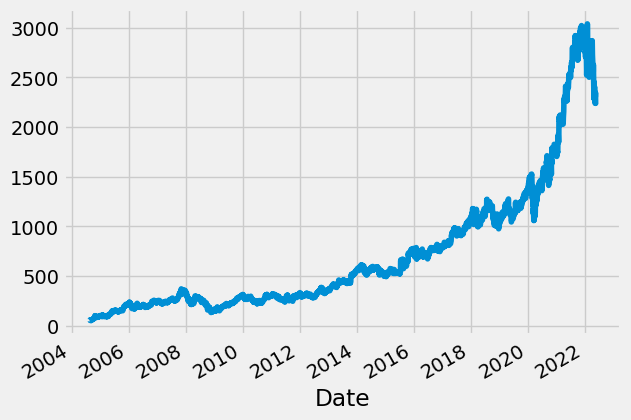

In [31]:
#Plot for Opening from years 2004 to 2022 for google
google['Open'].plot()

plt.show()

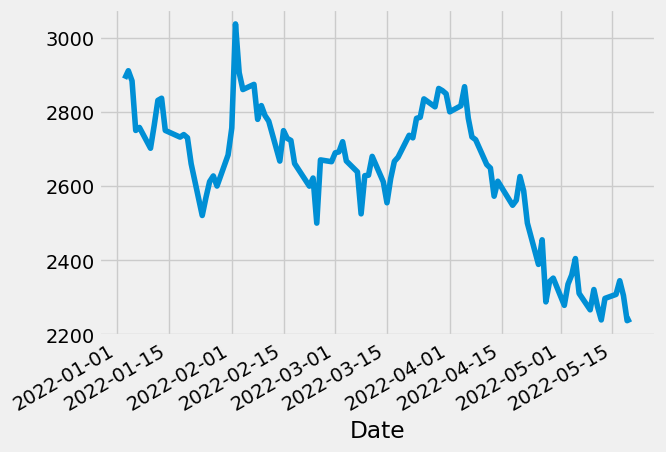

In [32]:
#Plot for Opening in 2022:
google.loc['2022']['Open'].plot()
plt.show()

**Important Points**
1. Its always a good practise to set the index as Date for Time Series analysis. This allows you to access specific data convineently using the loc.
2. 